In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("llm_price_performance_tracker_2026-03-31.csv")
df.head()

,model_name,model_slug,provider,provider_slug,aa_id,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,...,arena_elo_ci95,arena_votes,parameter_count,release_year,is_open_source,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar,scrape_date
0,GPT-5.4 (xhigh),gpt-5-4,OpenAI,openai,a89c4b28-2d8c-456e-88ea-255fb51fd2b6,57.2,57.3,NaN,63.40,NaN,...,8.0,5618.0,500.0,2026.0,False,10.17,33.53,80.68,15.94,3/31/2026
1,Gemini 3.1 Pro Preview,gemini-3-1-pro-preview,Google,google,bbd93ebe-80da-4594-bb19-61e69d0331df,57.2,55.5,NaN,65.90,NaN,...,6.0,15809.0,NaN,2026.0,False,12.71,38.66,96.02,26.71,3/31/2026
2,GPT-5.3 Codex (xhigh),gpt-5-3-codex,OpenAI,openai,59b5b14b-5365-4ee7-824a-18a8e6309644,54.0,53.1,NaN,61.53,NaN,...,NaN,NaN,500.0,2026.0,False,11.22,34.96,NaN,19.01,3/31/2026
3,"Claude Opus 4.6 (Adaptive Reasoning, Max Effort)",claude-opus-4-6-adaptive,Anthropic,anthropic,53c98840-47af-49aa-94e6-469fb17e9a1b,53.0,48.1,NaN,59.40,NaN,...,NaN,NaN,NaN,2025.0,False,5.30,24.77,NaN,6.06,3/31/2026
4,"Claude Sonnet 4.6 (Adaptive Reasoning, Max Eff...",claude-sonnet-4-6-adaptive,Anthropic,anthropic,df8d14e0-3997-4e4d-b4ad-9c047acc9c69,51.7,50.9,NaN,54.77,NaN,...,NaN,NaN,NaN,2025.0,False,8.62,28.14,NaN,12.90,3/31/2026


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   model_name                453 non-null    object 
 1   model_slug                453 non-null    object 
 2   provider                  453 non-null    object 
 3   provider_slug             453 non-null    object 
 4   aa_id                     453 non-null    object 
 5   aa_intelligence_index     446 non-null    float64
 6   aa_coding_index           356 non-null    float64
 7   aa_math_index             268 non-null    float64
 8   composite_benchmark       433 non-null    float64
 9   mmlu_pro                  344 non-null    float64
 10  gpqa_diamond              424 non-null    float64
 11  humanitys_last_exam       420 non-null    float64
 12  livecodebench             342 non-null    float64
 13  scicode                   418 non-null    float64
 14  math_500  

In [4]:
df.describe()

,aa_intelligence_index,aa_coding_index,aa_math_index,composite_benchmark,mmlu_pro,gpqa_diamond,humanitys_last_exam,livecodebench,scicode,math_500,...,time_to_first_answer_s,chatbot_arena_elo,arena_elo_ci95,arena_votes,parameter_count,release_year,intelligence_per_dollar,price_performance_ratio,elo_benchmark_blend,speed_per_dollar
count,446.000000,356.000000,268.000000,433.000000,344.000000,424.000000,420.000000,342.000000,418.000000,201.000000,...,279.000000,46.000000,46.000000,46.000000,286.000000,292.000000,297.000000,295.000000,46.00000,263.000000
mean,21.241256,19.507022,50.358209,43.885358,0.695875,0.597344,0.089479,0.444488,0.282156,0.763821,...,13.234559,1441.586957,5.500000,28526.456522,168.665734,2025.304795,56.694377,132.377085,45.59087,652.151863
std,11.969957,12.756695,30.683282,15.960437,0.167493,0.193779,0.074591,0.250330,0.126316,0.218255,...,21.447354,23.408997,1.929306,23704.998901,234.257631,0.853280,80.906908,140.634859,22.16947,2010.831957
min,4.700000,0.000000,0.000000,4.100000,0.055000,0.098000,0.012000,0.002000,0.000000,0.059000,...,0.199000,1412.000000,3.000000,2860.000000,0.600000,2023.000000,0.100000,9.730000,13.51000,0.790000
25%,12.000000,10.000000,23.350000,33.670000,0.633750,0.433750,0.044000,0.235750,0.193250,0.677000,...,0.582000,1422.000000,4.000000,11526.250000,9.250000,2025.000000,10.760000,42.620000,26.02250,38.315000
50%,17.950000,16.650000,52.800000,45.720000,0.752000,0.623000,0.055500,0.423000,0.295500,0.835000,...,1.551000,1436.500000,5.000000,20967.000000,49.000000,2026.000000,29.700000,82.940000,42.54500,119.170000
75%,28.475000,28.750000,79.475000,53.860000,0.814250,0.764000,0.103000,0.667500,0.377000,0.939000,...,18.249000,1454.000000,6.000000,38311.500000,235.000000,2026.000000,70.340000,174.565000,63.39500,473.960000
max,57.200000,57.300000,99.000000,95.400000,0.898000,0.941000,0.447000,0.917000,0.589000,0.994000,...,159.489000,1500.000000,11.000000,103891.000000,1200.000000,2026.000000,525.000000,1135.680000,96.02000,20735.850000


In [5]:
df.shape

(453, 34)

In [6]:
df.isnull().sum()

model_name                    0
model_slug                    0
provider                      0
provider_slug                 0
aa_id                         0
aa_intelligence_index         7
aa_coding_index              97
aa_math_index               185
composite_benchmark          20
mmlu_pro                    109
gpqa_diamond                 29
humanitys_last_exam          33
livecodebench               111
scicode                      35
math_500                    252
aime_2025                   259
input_cost_usd_per_1m       138
output_cost_usd_per_1m      138
blended_cost_usd_per_1m     138
pricing_tier                  0
output_tokens_per_second    174
time_to_first_token_s       174
time_to_first_answer_s      174
chatbot_arena_elo           407
arena_elo_ci95              407
arena_votes                 407
parameter_count             167
release_year                161
is_open_source                0
intelligence_per_dollar     156
price_performance_ratio     158
elo_benc

# Data Cleaning

In [7]:
df_clean = df.copy()

# We will be handling missing values for the impute columns by imputing the median based on their pricing tier.
impute_cols = [
    'aa_intelligence_index', 'aa_coding_index', 'aa_math_index',
    'composite_benchmark', 'mmlu_pro', 'gpqa_diamond',
    'humanitys_last_exam', 'livecodebench', 'scicode',
    'math_500', 'aime_2025',
]

for col in impute_cols:
    df_clean[col] = df_clean.groupby('pricing_tier')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Check the rest of the missing data that needs to be handled
print(df_clean.isnull().sum())


model_name                    0
model_slug                    0
provider                      0
provider_slug                 0
aa_id                         0
aa_intelligence_index         0
aa_coding_index               0
aa_math_index                 0
composite_benchmark           0
mmlu_pro                      0
gpqa_diamond                  0
humanitys_last_exam           0
livecodebench                 0
scicode                       0
math_500                      0
aime_2025                     0
input_cost_usd_per_1m       138
output_cost_usd_per_1m      138
blended_cost_usd_per_1m     138
pricing_tier                  0
output_tokens_per_second    174
time_to_first_token_s       174
time_to_first_answer_s      174
chatbot_arena_elo           407
arena_elo_ci95              407
arena_votes                 407
parameter_count             167
release_year                161
is_open_source                0
intelligence_per_dollar     156
price_performance_ratio     158
elo_benc

In [8]:
# Drop the columns that around 90% missing
drop_cols = ['chatbot_arena_elo', 'arena_elo_ci95', 'arena_votes', 'elo_benchmark_blend']
df_clean = df_clean.drop(columns=drop_cols)

# check the rest of the missing data needed to be handled
df_clean.isnull().sum()

model_name                    0
model_slug                    0
provider                      0
provider_slug                 0
aa_id                         0
aa_intelligence_index         0
aa_coding_index               0
aa_math_index                 0
composite_benchmark           0
mmlu_pro                      0
gpqa_diamond                  0
humanitys_last_exam           0
livecodebench                 0
scicode                       0
math_500                      0
aime_2025                     0
input_cost_usd_per_1m       138
output_cost_usd_per_1m      138
blended_cost_usd_per_1m     138
pricing_tier                  0
output_tokens_per_second    174
time_to_first_token_s       174
time_to_first_answer_s      174
parameter_count             167
release_year                161
is_open_source                0
intelligence_per_dollar     156
price_performance_ratio     158
speed_per_dollar            190
scrape_date                   0
dtype: int64

The cost columns, input_cost_usd_per_1m, output_cost_usd_per_1m, and blended_cost_usd_per_1m, each had 138 missing values. These missing values matched the same 138 rows where pricing_tier was listed as Unknown. Because of that, we did not fill in the missing cost values, since doing that would basically mean we are making up prices.

The speed and latency columns, output_tokens_per_second, time_to_first_token_s, and time_to_first_answer_s, had 174 missing values. In these cases, the providers did not give Artificial Analysis that speed or latency information. Since there was no actual measured value to go off of, it would not make sense to impute these.

parameter_count had 167 missing values. We left those as is because filling them in would make it seem like those closed-source models had a known parameter size when in reality that information was not available.

release_year had 161 missing values because the release dates were not available for every model in the dataset.

The columns intelligence_per_dollar, price_performance_ratio, and speed_per_dollar are derived metrics. Since they depend on cost and benchmark information, they were missing wherever the cost values were missing. We left those as is too because they cannot be recomputed without the missing pricing data.

# Feature Engineering / Deriving Features

In [9]:
# intelligence_to_speed_ratio: aa_intelligence_index divided by output_tokens_per_second. This is to checks if the smarter a model is the slower it will
# be and the higher this ratio means stronger model but slower output
df_clean['intelligence_to_speed_ratio'] = (df_clean['aa_intelligence_index'] / df_clean['output_tokens_per_second'])

# is_premium: binary flag to capture whether a model is in the Premium or Ultra pricing tier. This helps turn the pricing teir into something numeric.
df_clean['is_premium'] = df_clean['pricing_tier'].isin(['Premium', 'Ultra']).astype(int)

# is_recent: binary flag for models released in 2024 or later. 1 if a model is from 2024 or later 0 anywhere else. Newer models seem to be cheaper.
df_clean['is_recent'] = (df_clean['release_year'] >= 2024).astype(int)

# Missing release years stay as 0 here

# 1 if parameter count is known 0 everywhere else.
df_clean['parameter_known'] = df_clean['parameter_count'].notna().astype(int)

# this fills the missing parameter counts with 0
df_clean['parameter_count'] = df_clean['parameter_count'].fillna(0)

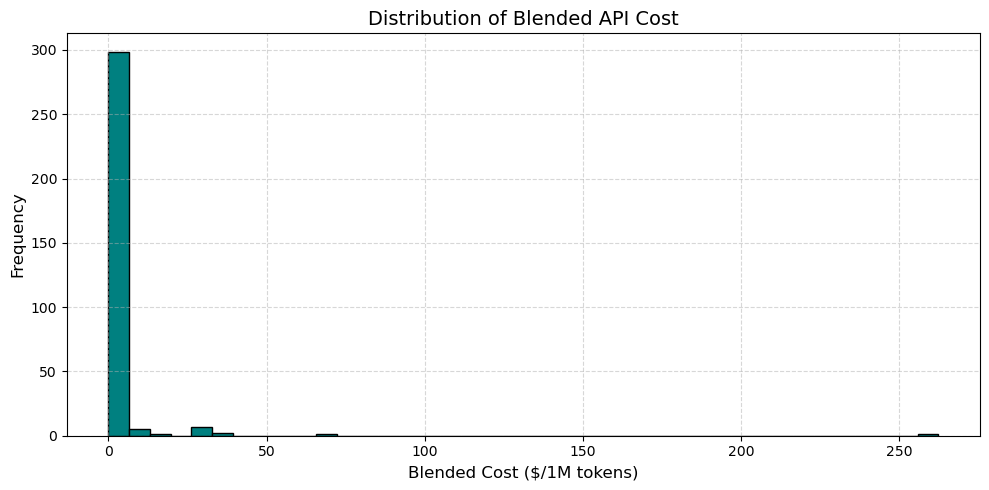

In [10]:
# Distribution of blended cost
plt.figure(figsize=(10, 5))
df_cost = df_clean.dropna(subset=['blended_cost_usd_per_1m'])
plt.hist(df_cost['blended_cost_usd_per_1m'], bins=40, color='teal', edgecolor='black')
plt.title('Distribution of Blended API Cost', fontsize=14)
plt.xlabel('Blended Cost ($/1M tokens)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Data Exploration Tasks 1, 2, & 3: 

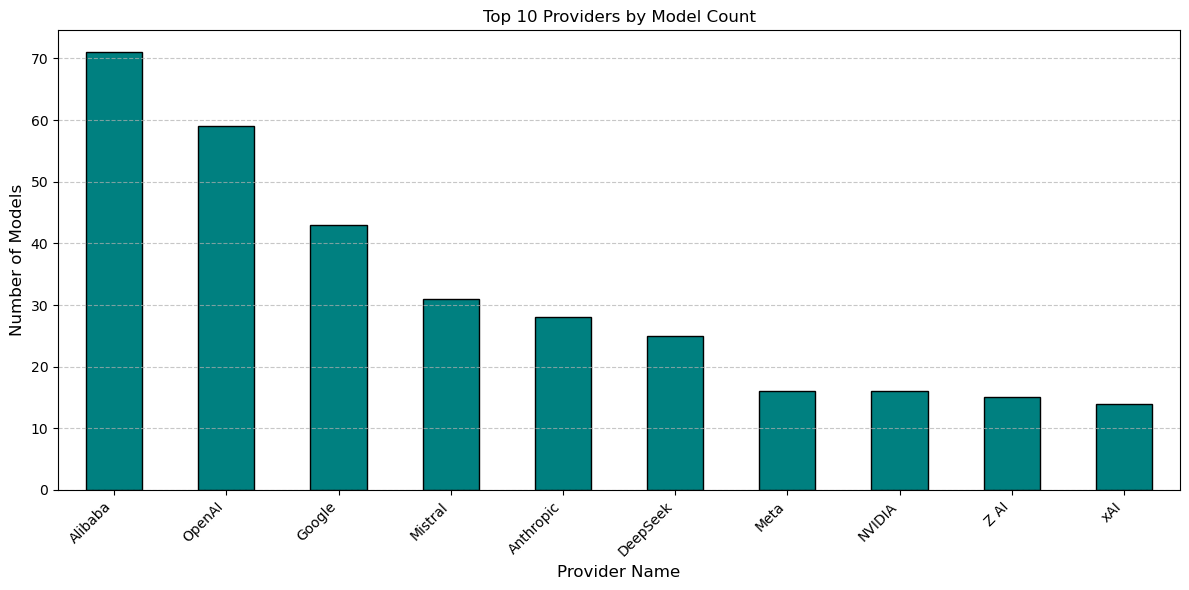

provider
Alibaba      71
OpenAI       59
Google       43
Mistral      31
Anthropic    28
DeepSeek     25
Meta         16
NVIDIA       16
Z AI         15
xAI          14
Name: count, dtype: int64


In [11]:
# Task 1. Top 10 Providers by Model Count
top10Providers = df_clean['provider'].value_counts().head(10)

plt.figure(figsize=(12,6))
top10Providers.plot(kind='bar', color='teal', edgecolor='black')

plt.title('Top 10 Providers by Model Count')
plt.xlabel('Provider Name', fontsize=12)
plt.ylabel('Number of Models', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(top10Providers)

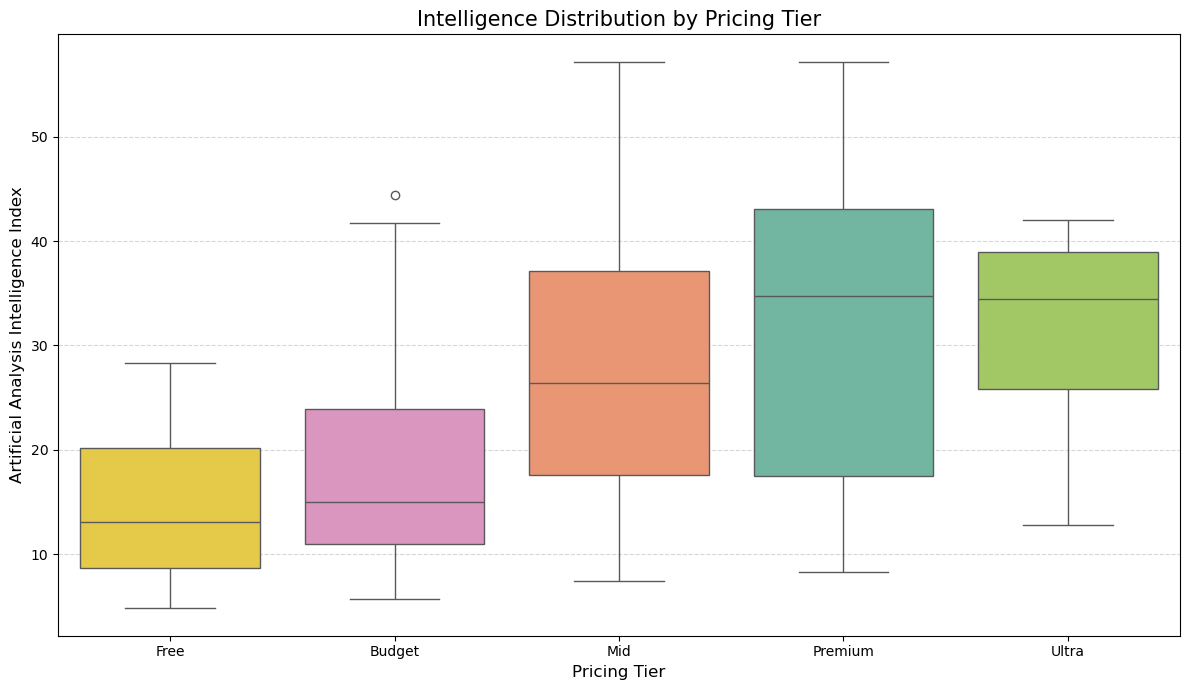

In [12]:
# Task 2. A box plot of intelligence distribution of different models by pricing tier.
tiers = ['Free', 'Budget', 'Mid', 'Premium', 'Ultra']

plt.figure(figsize=(12,7))
sns.boxplot(x='pricing_tier', y='aa_intelligence_index', data=df_clean, order=tiers, palette='Set2', hue='pricing_tier', legend=False)
plt.title('Intelligence Distribution by Pricing Tier', fontsize=15)
plt.xlabel('Pricing Tier', fontsize=12)
plt.ylabel('Artificial Analysis Intelligence Index', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
# Task 3. Find top-5 models on 5 benchmarks  (GPQA Diamond','Humanity's Last Exam','LiveCodeBench','SciCode','MATH-500')
benchmarks = ['gpqa_diamond', 'humanitys_last_exam', 'livecodebench', 'scicode', 'math_500']

for bench in benchmarks:
    top_models = df_clean.nlargest(5, bench)[['model_name', bench]]
    print(f"Top 5 Models - {bench}")
    print(top_models.to_string(index=False, justify='left'))
    print("=" * 60)

Top 5 Models - gpqa_diamond
model_name                   gpqa_diamond
     Gemini 3.1 Pro Preview 0.941        
            GPT-5.4 (xhigh) 0.920        
      GPT-5.3 Codex (xhigh) 0.915        
Gemini 3 Pro Preview (high) 0.908        
            GPT-5.2 (xhigh) 0.903        
Top 5 Models - humanitys_last_exam
model_name                                        humanitys_last_exam
                          Gemini 3.1 Pro Preview 0.447               
                                 GPT-5.4 (xhigh) 0.416               
                           GPT-5.3 Codex (xhigh) 0.399               
                     Gemini 3 Pro Preview (high) 0.372               
Claude Opus 4.6 (Adaptive Reasoning, Max Effort) 0.367               
Top 5 Models - livecodebench
model_name                          livecodebench
       Gemini 3 Pro Preview (high) 0.917         
Gemini 3 Flash Preview (Reasoning) 0.908         
            DeepSeek V3.2 Speciale 0.896         
                  GPT-5.2 (medium) 0

# Further EDA on features 

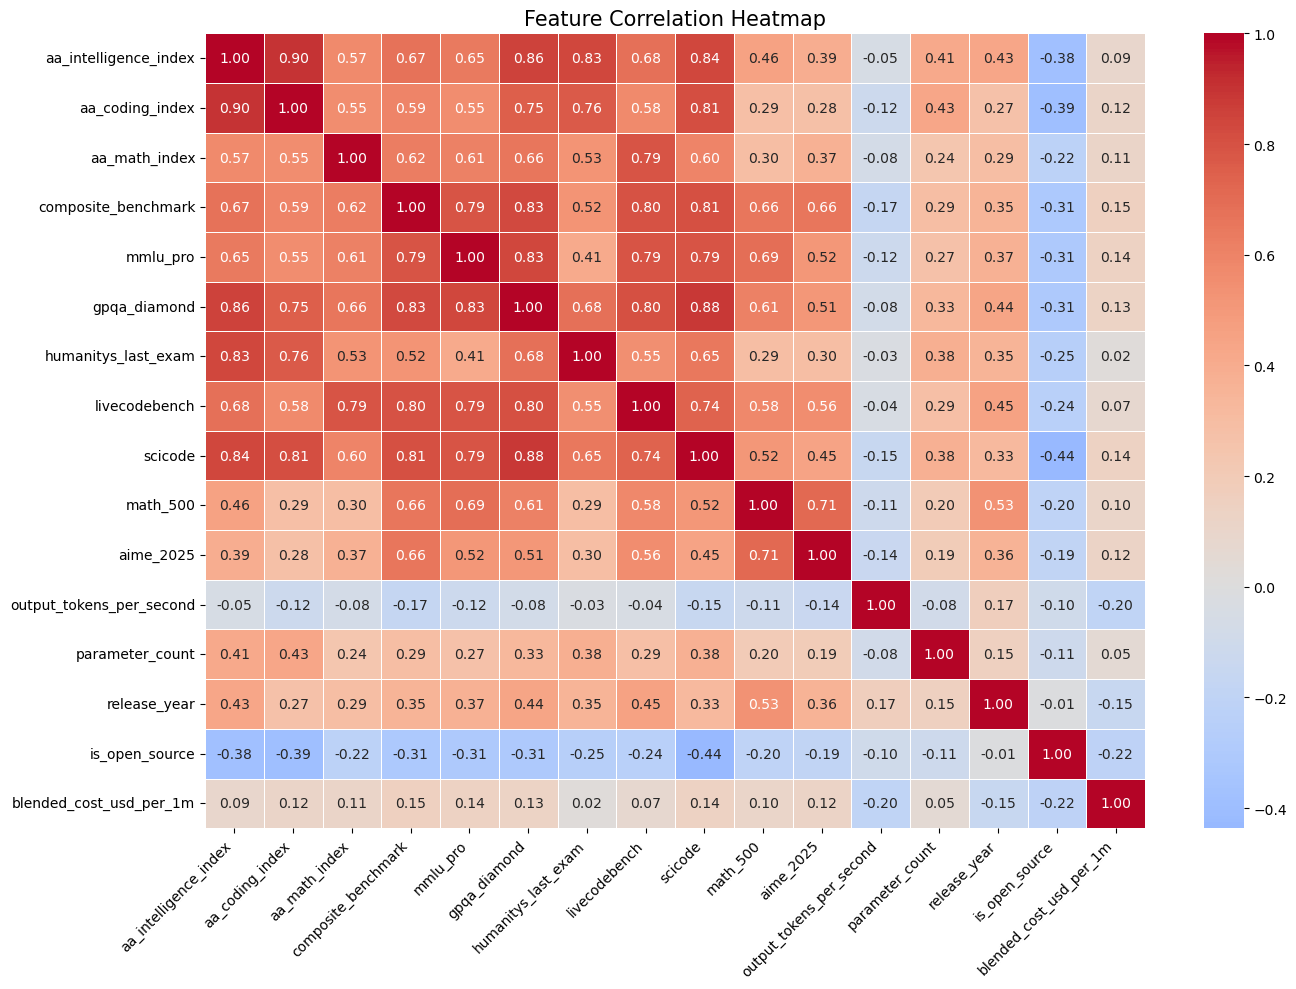

In [14]:
# Feature Correlation Analysis
feature_cols = [
    'aa_intelligence_index', 'aa_coding_index', 'aa_math_index',
    'composite_benchmark', 'mmlu_pro', 'gpqa_diamond',
    'humanitys_last_exam', 'livecodebench', 'scicode',
    'math_500', 'aime_2025', 'output_tokens_per_second',
    'parameter_count', 'release_year', 'is_open_source',
    'blended_cost_usd_per_1m'
]

corr_matrix = df_clean[feature_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Correlation of all features with blended cost
cost_corr = corr_matrix['blended_cost_usd_per_1m'].drop('blended_cost_usd_per_1m').sort_values(ascending=False)
print("Feature Correlations with Blended Cost:")
print("=" * 40)
print(cost_corr.to_string())

Feature Correlations with Blended Cost:
composite_benchmark         0.149626
mmlu_pro                    0.138718
scicode                     0.135918
gpqa_diamond                0.127491
aime_2025                   0.120190
aa_coding_index             0.115327
aa_math_index               0.110110
math_500                    0.103475
aa_intelligence_index       0.092902
livecodebench               0.070593
parameter_count             0.050372
humanitys_last_exam         0.021875
release_year               -0.145169
output_tokens_per_second   -0.200397
is_open_source             -0.217249


In [16]:
# Feature Selection Filter and Wrapper Methods to determine which features to include
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression, RFE

# features were selected based on the correlation matrix findings and prioritizing columns with the least amount of missing data so that there is a high
# number of complete rows available for SelectKBest and RFE to evaluate.
temp_cols = [
    'is_premium', 'is_open_source', 'gpqa_diamond', 'mmlu_pro',
    'parameter_known', 'composite_benchmark', 'aa_intelligence_index',
    'parameter_count', 'is_recent', 'blended_cost_usd_per_1m'
]

temp_df = df_clean[temp_cols].dropna().copy()
temp_df['log_cost'] = np.log1p(temp_df['blended_cost_usd_per_1m'])

X_all = temp_df.drop(columns=['blended_cost_usd_per_1m', 'log_cost'])
y_all = temp_df['log_cost']

# Filter method SelectKBest
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_all, y_all)

filter_df = pd.DataFrame({
    'Feature': X_all.columns,
    'Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values('Score', ascending=False)

print("Filter Method - SelectKBest Scores:")
print("=" * 50)
print(filter_df.to_string(index=False))

# Wrapper method RFE
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(X_all, y_all)

rfe_df = pd.DataFrame({
    'Feature': X_all.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("\nWrapper Method - RFE Rankings:")
print("=" * 50)
print(rfe_df.to_string(index=False))

Filter Method - SelectKBest Scores:
              Feature      Score      P-Value
           is_premium 399.486985 7.438458e-58
       is_open_source 132.984042 7.040594e-26
  composite_benchmark  62.312318 4.980496e-14
aa_intelligence_index  54.346171 1.511944e-12
             mmlu_pro  49.095421 1.500409e-11
         gpqa_diamond  45.993124 5.926539e-11
      parameter_count  11.263242 8.879663e-04
      parameter_known  10.226461 1.526018e-03
            is_recent   0.000136 9.906872e-01

Wrapper Method - RFE Rankings:
              Feature  Selected  Ranking
           is_premium      True        1
       is_open_source      True        1
             mmlu_pro      True        1
      parameter_known      True        1
            is_recent      True        1
         gpqa_diamond     False        2
  composite_benchmark     False        3
aa_intelligence_index     False        4
      parameter_count     False        5


In [17]:
# Selected features based of EDA, Correlation, Filter, and wrapper methods: 
selected_features = [
    'is_premium',
    'is_open_source', 
    'gpqa_diamond',
    'mmlu_pro',
    'parameter_known',
    'composite_benchmark',
    'output_tokens_per_second'
    
]

# API Cost Modeling and Forecasting

Top 3 Models Selected for Projection:
Top 3 Models Selected for Projection:
                                      model_name  aa_intelligence_index
                                 GPT-5.4 (xhigh)                   57.2
                           Kimi K2.5 (Reasoning)                   46.8
Claude Opus 4.6 (Adaptive Reasoning, Max Effort)                   53.0
Linear Regression - MSE: 0.1696 | R2: 0.6857
Random Forest - MSE: 0.1851 | R2: 0.6570

Best model: Linear Regression


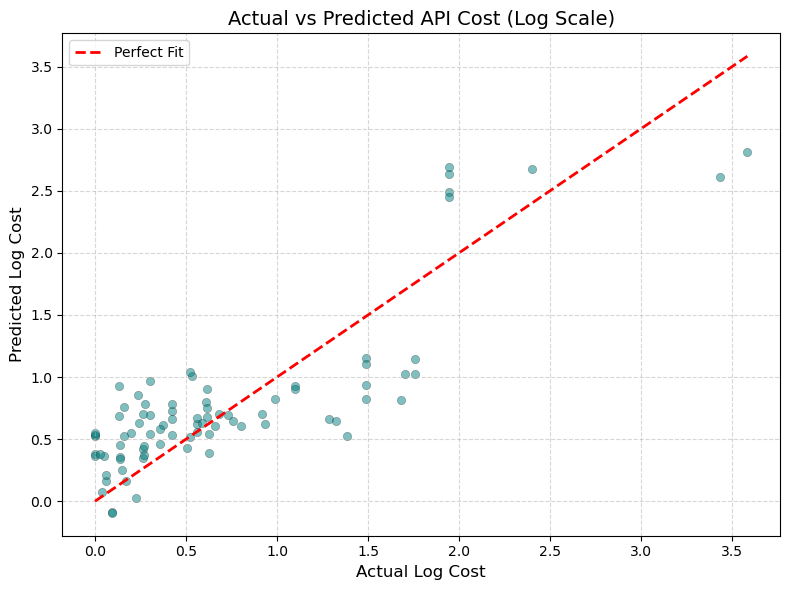


Top 3 Models - Projected API Cost from LinearRegression():
GPT-5.4 (xhigh)
  Intelligence Score:  57.2
  Actual Cost:         $5.62 per 1M tokens
  Predicted Cost:      $11.39 per 1M tokens

Kimi K2.5 (Reasoning)
  Intelligence Score:  46.8
  Actual Cost:         $1.20 per 1M tokens
  Predicted Cost:      $1.00 per 1M tokens

Claude Opus 4.6 (Adaptive Reasoning, Max Effort)
  Intelligence Score:  53.0
  Actual Cost:         $10.00 per 1M tokens
  Predicted Cost:      $11.70 per 1M tokens



In [28]:
# API Cost Modeling and Forecasting
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Identify top 3 models by intelligence before training
ranking_df = df_clean.dropna(subset=['aa_intelligence_index', 'intelligence_to_speed_ratio']).copy()

# Normalize both features to 0-1 scale so they contribute equally
ranking_df['norm_intelligence'] = (
    (ranking_df['aa_intelligence_index'] - ranking_df['aa_intelligence_index'].min()) /
    (ranking_df['aa_intelligence_index'].max() - ranking_df['aa_intelligence_index'].min())
)
ranking_df['norm_speed_ratio'] = (
    (ranking_df['intelligence_to_speed_ratio'] - ranking_df['intelligence_to_speed_ratio'].min()) /
    (ranking_df['intelligence_to_speed_ratio'].max() - ranking_df['intelligence_to_speed_ratio'].min())
)

# Composite score weighted 70% intelligence, 30% intelligence_to_speed_ratio
ranking_df['composite_score'] = (0.7 * ranking_df['norm_intelligence'] + 0.3 * ranking_df['norm_speed_ratio'])

top3 = ranking_df.nlargest(3, 'composite_score')
print("Top 3 Models Selected for Projection:")
print("Top 3 Models Selected for Projection:")
print("=" * 60)
print(top3[['model_name', 'aa_intelligence_index']].to_string(index=False))


model_cols = selected_features + ['blended_cost_usd_per_1m']

# Remove top 3 from dataset before training
model_df = df_clean[model_cols].dropna().copy()
model_df = model_df[~model_df.index.isin(top3.index)]

# Log transform target to handle skewed cost distribution
model_df['log_cost'] = np.log1p(model_df['blended_cost_usd_per_1m'])

X = model_df.drop(columns=['blended_cost_usd_per_1m', 'log_cost'])
y = model_df['log_cost']

# Stratified 70/30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=df_clean.loc[model_df.index, 'pricing_tier'])

# Train Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression - MSE: {mse:.4f} | R2: {r2:.4f}")

#train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MSE: {mse_rf:.4f} | R2: {r2_rf:.4f}")

# Pick the better model
best_model = model if r2 >= r2_rf else rf_model
best_name = "Linear Regression" if r2 >= r2_rf else "Random Forest"
print(f"\nBest model: {best_name}")

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', edgecolors='black', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Log Cost', fontsize=12)
plt.ylabel('Predicted Log Cost', fontsize=12)
plt.title('Actual vs Predicted API Cost (Log Scale)', fontsize=14)
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Project cost for top 3 models
top3_features = top3.reindex(columns=X_train.columns).fillna(0)
top3_log_pred = best_model.predict(top3_features)
top3_pred_cost = np.expm1(top3_log_pred)

print(f"\nTop 3 Models - Projected API Cost from {best_model}:")
print("=" * 60)
for idx, (i, row) in enumerate(top3.iterrows()):
    actual = row['blended_cost_usd_per_1m']
    predicted = top3_pred_cost[idx]
    print(f"{row['model_name']}")
    print(f"  Intelligence Score:  {row['aa_intelligence_index']:.1f}")
    print(f"  Actual Cost:         ${actual:.2f} per 1M tokens")
    print(f"  Predicted Cost:      ${predicted:.2f} per 1M tokens")
    print()

# Temporal capability tracking & Price Compression

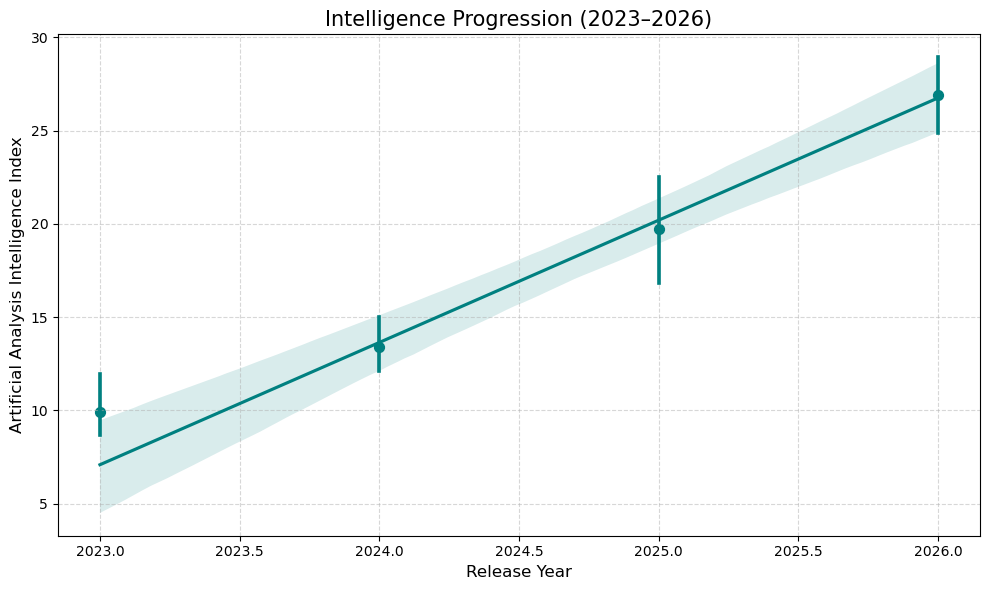

In [19]:
# Intelligence Progression (2023-2026)
df_temporal = df_clean.dropna(subset=['release_year', 'aa_intelligence_index'])

plt.figure(figsize=(10, 6))
sns.regplot(x='release_year', y='aa_intelligence_index', 
            data=df_temporal, x_estimator=np.mean, color='teal')
plt.title('Intelligence Progression (2023–2026)', fontsize=15)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Artificial Analysis Intelligence Index', fontsize=12)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

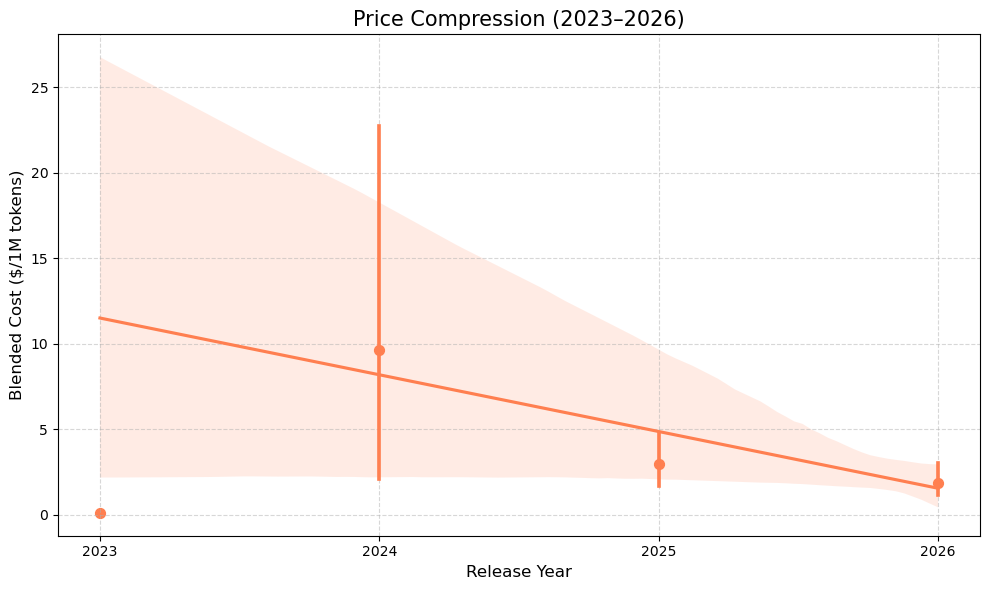

In [20]:
# Price Compression (2023-2026)
df_temporal = df_clean.dropna(subset=['release_year', 'blended_cost_usd_per_1m'])

plt.figure(figsize=(10, 6))
sns.regplot(x='release_year', y='blended_cost_usd_per_1m',
            data=df_temporal, x_estimator=np.mean, color='coral')
plt.title('Price Compression (2023–2026)', fontsize=15)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Blended Cost ($/1M tokens)', fontsize=12)
plt.xticks([2023, 2024, 2025, 2026])
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()